In [1]:
%pip install cupy-cuda13x

  Using cached cupy_cuda13x-14.0.1-cp314-cp314-win_amd64.whl.metadata (2.8 kB)
  Using cached numpy-2.4.3-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached cuda_pathfinder-1.4.3-py3-none-any.whl.metadata (1.9 kB)
Using cached cupy_cuda13x-14.0.1-cp314-cp314-win_amd64.whl (35.5 MB)
Using cached cuda_pathfinder-1.4.3-py3-none-any.whl (47 kB)
Using cached numpy-2.4.3-cp314-cp314-win_amd64.whl (12.4 MB)

   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ---------------------------------------- 0/3 [numpy]
   ------------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import numpy as np
import cupy as cp
import time
import pandas as pd
import matplotlib.pyplot as plt
import csv
import sys

### Задание 1.

Поэлементные операции с большими массивами.

На вход функции подаётся массив размерностью $N$. Необходимо реализовать вычисление выражения $y = \sqrt{x}+sin(x)⋅exp(−x)$ (используйте встроенные векторные функции, обычный for не даст вам ускорения). Для экспериментов ограничим значение, которое может принимать $N$ в задачах следующим интервалом [1, 10000000].

In [13]:
def compute_numpy(x):
    return np.sqrt(x) + np.sin(x) * np.exp(-x)

def compute_cupy(x):
    return cp.sqrt(x) + cp.sin(x) * cp.exp(-x)

In [14]:
N = []
result1 = []
result2 = []
for n in range(1, 10000000, 10000):
  # NumPy
  start = time.time()
  x_cpu = np.random.rand(n).astype(np.float32)
  _ = compute_numpy(x_cpu)
  finish = time.time()
  res1 = finish - start

  # CuPy
  start = time.time()
  x_gpu = cp.random.rand(n).astype(cp.float32)
  _ = compute_cupy(x_gpu)
  finish = time.time()
  res2 = finish - start

  print(f"N = {n:<5}\tNumPy: {res1: .6f}\tCuPy: {res2: .6f}")
  N.append(n)
  result1.append(res1)
  result2.append(res2)

data = {'N': N, 'CPU': result1, 'GPU': result2}

df = pd.DataFrame(data)
df.to_csv('file1.csv', index=False)

N = 1    	NumPy:  0.000085	CuPy:  0.001020
N = 10001	NumPy:  0.000523	CuPy:  0.000270
N = 20001	NumPy:  0.000199	CuPy:  0.000250
N = 30001	NumPy:  0.000290	CuPy:  0.000205
N = 40001	NumPy:  0.000458	CuPy:  0.000208
N = 50001	NumPy:  0.000672	CuPy:  0.000259
N = 60001	NumPy:  0.000814	CuPy:  0.000449
N = 70001	NumPy:  0.001005	CuPy:  0.000247
N = 80001	NumPy:  0.001236	CuPy:  0.000428
N = 90001	NumPy:  0.001492	CuPy:  0.000463
N = 100001	NumPy:  0.001346	CuPy:  0.000250
N = 110001	NumPy:  0.001032	CuPy:  0.000215
N = 120001	NumPy:  0.001301	CuPy:  0.000203
N = 130001	NumPy:  0.002014	CuPy:  0.000234
N = 140001	NumPy:  0.001910	CuPy:  0.000234
N = 150001	NumPy:  0.001708	CuPy:  0.000212
N = 160001	NumPy:  0.001636	CuPy:  0.000212
N = 170001	NumPy:  0.001726	CuPy:  0.000210
N = 180001	NumPy:  0.002578	CuPy:  0.000365
N = 190001	NumPy:  0.003648	CuPy:  0.000600
N = 200001	NumPy:  0.002768	CuPy:  0.000224
N = 210001	NumPy:  0.002345	CuPy:  0.000216
N = 220001	NumPy:  0.002608	CuPy:  0.00030

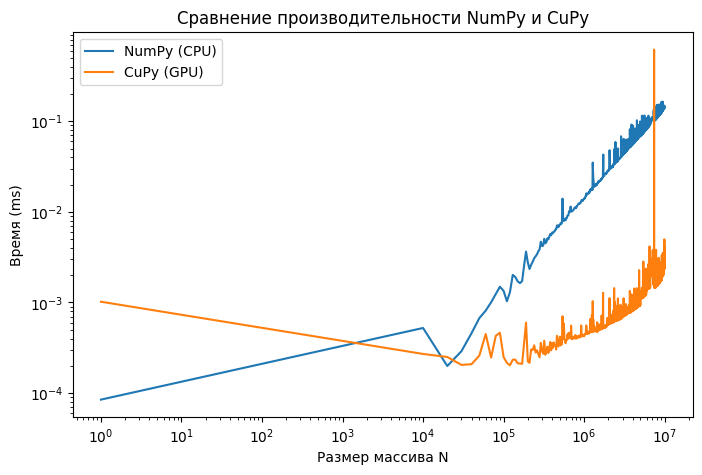

In [16]:
plt.figure(figsize=(8,5))
plt.loglog(df['N'], df['CPU'], label='NumPy (CPU)')
plt.loglog(df['N'], df['GPU'], label='CuPy (GPU)')
plt.xlabel('Размер массива N')
plt.ylabel('Время (ms)')
plt.title('Сравнение производительности NumPy и CuPy')
plt.legend()
plt.show()

### Задание 2.

Расчет статистик.

На вход функции подаётся квадртаная матрицы $A$ размерностью $N \times N$. Необходимо реализовать функцию рассчета статистик (среднее значение, медиана, мода, дисперсия, среднеквадартаичное отклонение, первый и третий квартиль) для каждой колонки матрицы. Для экспериментов ограничим значение, которое может принимать $N$ в задачах следующим интервалом [1, 100000].

In [17]:
def mode_np(A):
  modes = np.zeros(A.shape[1], dtype=A.dtype)
  for i in range(A.shape[1]):
    vals, counts = np.unique(A[:, i], return_counts=True)
    modes[i] = vals[np.argmax(counts)]
  return modes

def mode_cp(A):
  modes = cp.zeros(A.shape[1], dtype=A.dtype)
  for i in range(A.shape[1]):
    vals, counts = cp.unique(A[:, i], return_counts=True)
    modes[i] = vals[cp.argmax(counts)]
  return modes

def statics_np(A):
  return(
    np.mean(A, axis=0),
    np.median(A, axis=0),
    np.var(A, axis=0, ddof=0),
    np.std(A, axis=0, ddof=0),
    np.percentile(A, 25, axis=0),
    np.percentile(A, 75, axis=0),
    mode_np(A)
  )

def statics_cp(A):
  return(
    cp.mean(A, axis=0),
    cp.median(A, axis=0),
    cp.var(A, axis=0, ddof=0),
    cp.std(A, axis=0, ddof=0),
    cp.percentile(A, 25, axis=0),
    cp.percentile(A, 75, axis=0),
    mode_cp(A)
  )

In [18]:
def run_numpy(N):
    start = time.time()
    A = np.random.rand(N, N).astype(np.float16)
    _ = statics_np(A)
    end = time.time()
    del A
    return end - start

def run_cupy(N):
    start = time.time()
    A = cp.random.rand(N, N).astype(cp.float16)
    _ = statics_cp(A)
    end = time.time()
    del A
    return end - start

In [19]:
def main():
    with open('file2.csv', 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['N', 'time_numpy', 'time_cupy'])

    for i in range(1, 30000, 1000):
        t_np = run_numpy(i)
        t_cp = run_cupy(i)

        print(f"N = {i:<5}\tNumPy: {t_np: .3f}\tCuPy: {t_cp: .3f}")

        with open('file2.csv', 'a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow([i, t_np, t_cp])

if __name__ == '__main__':
    main()

N = 1    	NumPy:  0.012	CuPy:  7.689
N = 1001 	NumPy:  0.187	CuPy:  2.716
N = 2001 	NumPy:  0.820	CuPy:  1.883
N = 3001 	NumPy:  1.833	CuPy:  2.788
N = 4001 	NumPy:  3.251	CuPy:  4.096
N = 5001 	NumPy:  5.154	CuPy:  5.858
N = 6001 	NumPy:  7.454	CuPy:  8.432
N = 7001 	NumPy:  9.904	CuPy:  9.913
N = 8001 	NumPy:  12.999	CuPy:  10.148
N = 9001 	NumPy:  16.675	CuPy:  9.292
N = 10001	NumPy:  20.246	CuPy:  9.925
N = 11001	NumPy:  24.573	CuPy:  10.739
N = 12001	NumPy:  29.293	CuPy:  11.477
N = 13001	NumPy:  34.618	CuPy:  12.827
N = 14001	NumPy:  40.431	CuPy:  13.687
N = 15001	NumPy:  46.379	CuPy:  15.375
N = 16001	NumPy:  53.797	CuPy:  15.817
N = 17001	NumPy:  60.866	CuPy:  398.379
N = 18001	NumPy:  68.654	CuPy:  117.005
N = 19001	NumPy:  76.884	CuPy:  604.553
N = 20001	NumPy:  85.412	CuPy:  22.059
N = 21001	NumPy:  93.840	CuPy:  22.424
N = 22001	NumPy:  103.396	CuPy:  24.176
N = 23001	NumPy:  113.351	CuPy:  783.914
N = 24001	NumPy:  124.392	CuPy:  27.199
N = 25001	NumPy:  133.522	CuPy:  27.

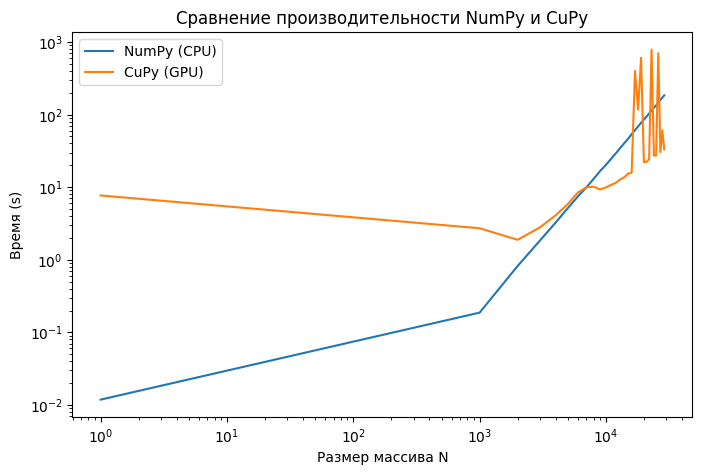

In [20]:
df = pd.read_csv('file2.csv')
plt.figure(figsize=(8,5))
plt.loglog(df['N'], df['time_numpy'], label='NumPy (CPU)')
plt.loglog(df['N'], df['time_cupy'], label='CuPy (GPU)')
plt.xlabel('Размер массива N')
plt.ylabel('Время (s)')
plt.title('Сравнение производительности NumPy и CuPy')
plt.legend()
plt.show()

### Задание 3.

Матричное умножение.

На вход функции подаётся две квадртаная матрицы $A$ и $B$ размерностью $N \times N$. Необходимо реализовать вычисление их произведения $C = A \cdot B$. Для экспериментов ограничим значение, которое может принимать $N$ в задачах следующим интервалом [1, 4096].

In [21]:
def matrix_numpy(N):
  start = time.time()
  A = np.random.rand(N, N)
  B = np.random.rand(N, N)
  _ = np.matmul(A, B)
  end = time.time()
  return end - start

def matrix_cupy(N):
  start = time.time()
  A = cp.random.rand(N, N)
  B = cp.random.rand(N, N)
  _ = cp.matmul(A, B)
  end = time.time()
  return end - start

In [22]:
def main():
    with open('file3.csv', 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['N', 'time_numpy', 'time_cupy'])

    for i in range(1, 4096, 127):
        np_matrix = matrix_numpy(i)
        cp_matrix = matrix_cupy(i)

        print(f"N = {i:<5}\tNumPy: {np_matrix: .6f}\tCuPy: {cp_matrix: .6f}")

        with open('file3.csv', 'a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow([i, np_matrix, cp_matrix])

if __name__ == '__main__':
    main()

N = 1    	NumPy:  0.000132	CuPy:  0.048874
N = 128  	NumPy:  0.002408	CuPy:  0.113533
N = 255  	NumPy:  0.001365	CuPy:  0.001127
N = 382  	NumPy:  0.003317	CuPy:  0.001930
N = 509  	NumPy:  0.004496	CuPy:  0.000255
N = 636  	NumPy:  0.007350	CuPy:  0.000332
N = 763  	NumPy:  0.010673	CuPy:  0.000704
N = 890  	NumPy:  0.014986	CuPy:  0.000279
N = 1017 	NumPy:  0.028592	CuPy:  0.000340
N = 1144 	NumPy:  0.025641	CuPy:  0.001380
N = 1271 	NumPy:  0.039164	CuPy:  0.000291
N = 1398 	NumPy:  0.046112	CuPy:  0.000281
N = 1525 	NumPy:  0.056664	CuPy:  0.000272
N = 1652 	NumPy:  0.071041	CuPy:  0.000269
N = 1779 	NumPy:  0.081307	CuPy:  0.000276
N = 1906 	NumPy:  0.097645	CuPy:  0.000269
N = 2033 	NumPy:  0.115890	CuPy:  0.000276
N = 2160 	NumPy:  0.133165	CuPy:  0.000718
N = 2287 	NumPy:  0.152221	CuPy:  0.000485
N = 2414 	NumPy:  0.183747	CuPy:  0.000359
N = 2541 	NumPy:  0.198367	CuPy:  0.000592
N = 2668 	NumPy:  0.231284	CuPy:  0.000416
N = 2795 	NumPy:  0.259260	CuPy:  0.000426
N = 2922 	N

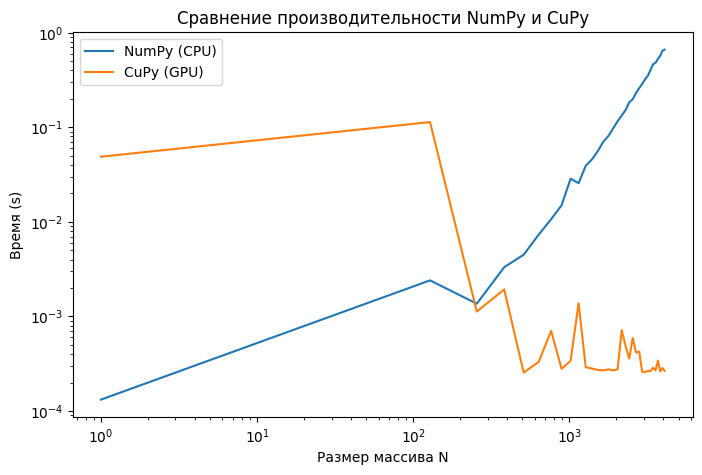

In [23]:
df = pd.read_csv('file3.csv')
plt.figure(figsize=(8,5))
plt.loglog(df['N'], df['time_numpy'], label='NumPy (CPU)')
plt.loglog(df['N'], df['time_cupy'], label='CuPy (GPU)')
plt.xlabel('Размер массива N')
plt.ylabel('Время (s)')
plt.title('Сравнение производительности NumPy и CuPy')
plt.legend()
plt.show()

### Задание 4.

Ряд Маклорена.

На вход подается массив размерностью $N$ со значениями [-10, 10] и число $M$ - количество многочленов для апрокимации. Необходимо реализовать функцию, которая вычисляет разложение функции $sin(x)$ в ряд Маклорена для заданного массива и количество многочленов для апрокимации. Для экспериментов ограничим значение, которое может принимать $N$ в задачах следующим интервалом [1, 10000000], а $M$ - одним, любым значением, но не меньше 5.

In [24]:
def numpy_sin(x, M):
    x = np.asarray(x, dtype=np.float32)
    x2 = x * x
    term = x.copy()
    result = term
    for k in range(1, M):
        factor = -x2 / ((2*k)*(2*k+1))
        term = term * factor
        result = result + term
    return result

def cupy_sin(x, M):
    x = cp.asarray(x, dtype=cp.float32)
    x2 = x * x
    term = x.copy()
    result = term
    for k in range(1, M):
        factor = -x2 / ((2*k)*(2*k+1))
        term = term * factor
        result = result + term
    return result

def time_numpy(N, M):
    x = np.random.uniform(-10, 10, size=N).astype(np.float32)
    start = time.time()
    _ = numpy_sin(x, M)
    end = time.time()
    return end - start

def time_cupy(N, M):
    x = cp.random.uniform(-10, 10, size=N, dtype=cp.float32)
    start = time.time()
    _ = cupy_sin(x, M)
    end = time.time()
    return end - start

In [25]:
def main():
    with open('file4.csv', 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['N', 'time_numpy', 'time_cupy'])

    M = 5
    for i in range(1, 10000000, 10000):
        t_np = time_numpy(i, M)
        t_cp = time_cupy(i, M)

        print(f"N = {i:<5}\tNumPy: {t_np: .6f}\tCuPy: {t_cp: .6f}")

        with open('file4.csv', 'a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow([i, t_np, t_cp])

if __name__ == '__main__':
    main()

N = 1    	NumPy:  0.000028	CuPy:  0.000843
N = 10001	NumPy:  0.000137	CuPy:  0.000482
N = 20001	NumPy:  0.000173	CuPy:  0.000499
N = 30001	NumPy:  0.000255	CuPy:  0.000886
N = 40001	NumPy:  0.000274	CuPy:  0.000436
N = 50001	NumPy:  0.000204	CuPy:  0.000456
N = 60001	NumPy:  0.000264	CuPy:  0.000445
N = 70001	NumPy:  0.000377	CuPy:  0.000453
N = 80001	NumPy:  0.000447	CuPy:  0.000435
N = 90001	NumPy:  0.000418	CuPy:  0.000515
N = 100001	NumPy:  0.000395	CuPy:  0.000429
N = 110001	NumPy:  0.000489	CuPy:  0.000540
N = 120001	NumPy:  0.000473	CuPy:  0.000571
N = 130001	NumPy:  0.000467	CuPy:  0.000429
N = 140001	NumPy:  0.000628	CuPy:  0.000418
N = 150001	NumPy:  0.000650	CuPy:  0.000443
N = 160001	NumPy:  0.000688	CuPy:  0.000431
N = 170001	NumPy:  0.000717	CuPy:  0.000433
N = 180001	NumPy:  0.000741	CuPy:  0.000421
N = 190001	NumPy:  0.000774	CuPy:  0.000409
N = 200001	NumPy:  0.000982	CuPy:  0.000404
N = 210001	NumPy:  0.001333	CuPy:  0.000412
N = 220001	NumPy:  0.001295	CuPy:  0.00057

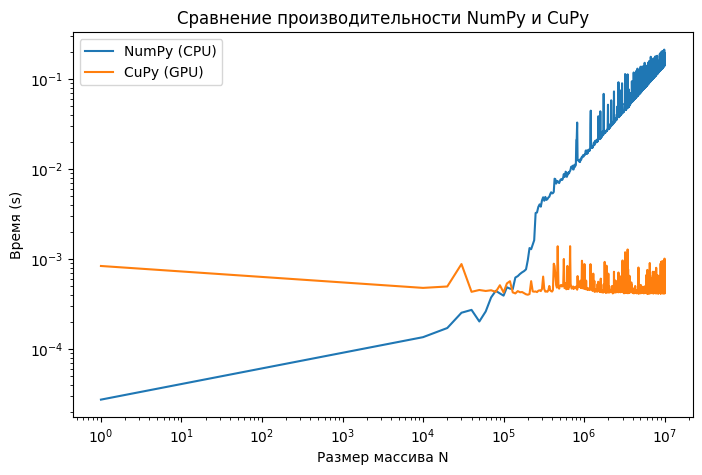

In [26]:
df = pd.read_csv('file4.csv')
plt.figure(figsize=(8,5))
plt.loglog(df['N'], df['time_numpy'], label='NumPy (CPU)')
plt.loglog(df['N'], df['time_cupy'], label='CuPy (GPU)')
plt.xlabel('Размер массива N')
plt.ylabel('Время (s)')
plt.title('Сравнение производительности NumPy и CuPy')
plt.legend()
plt.show()